## 🎯 Problem Statement
#### How do sector and role categories interact with educational qualification to influence salary levels in government job listings?

> This notebook investigates 652 government job postings to uncover how three key dimensions — **sector**, **role category**, and **educational qualification** — shape salary outcomes. We move from individual distributions to cross-dimensional patterns, building toward a coherent picture of where opportunity and compensation align in public-sector hiring.

## 💡 Insightful Questions
---
- Does higher qualification lead to higher salary?
- Which sectors pay more?
- Which roles dominate demand?
- Which sector hires mostly undergraduates?
- Are managerial roles always higher paying?
- Which roles have the highest salary variability?

# 📊 Trimmed Data Analysis

In [1]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_trimmed = pd.read_csv("../Data/Job_Data_Trimmed.csv")

In [6]:
df_trimmed

,Job Type,salary_minimum,salary_maximum,salary_band,salary_range,qualification_level,sector,role_category
0,Government,63000.0,63000.0,Medium,0.0,undergraduate,Banking,Officer
1,Government,25000.0,25000.0,Low,0.0,undergraduate,Government General,Associate
2,Government,30000.0,60000.0,Medium,30000.0,undergraduate,PSU,Other
3,Government,57700.0,182400.0,Medium,124700.0,postgraduate,Government Admin,Academic
4,Government,25000.0,25000.0,Low,0.0,undergraduate,PSU,Engineer
...,...,...,...,...,...,...,...,...
647,Government,44900.0,142400.0,Medium,97500.0,undergraduate,Healthcare,Officer
648,Government,31000.0,31000.0,Medium,0.0,other,Education,Research
649,Government,37000.0,37000.0,Medium,0.0,undergraduate,Education,Engineer
650,Government,78800.0,209200.0,High,130400.0,undergraduate,Government General,Managerial


In [3]:
df_trimmed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 652 entries, 0 to 651
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Job Type             652 non-null    object 
 1   salary_minimum       652 non-null    float64
 2   salary_maximum       652 non-null    float64
 3   salary_band          652 non-null    object 
 4   salary_range         652 non-null    float64
 5   qualification_level  652 non-null    object 
 6   sector               652 non-null    object 
 7   role_category        652 non-null    object 
dtypes: float64(3), object(5)
memory usage: 40.9+ KB


## 1️⃣ Numerical Data Analysis

### 💰 Salary Data Analysis

In [4]:
df_trimmed["salary_minimum"]

0       63000.0
1       25000.0
2       30000.0
3       57700.0
4       25000.0
         ...   
647     44900.0
648     31000.0
649     37000.0
650     78800.0
651    150000.0
Name: salary_minimum, Length: 652, dtype: float64

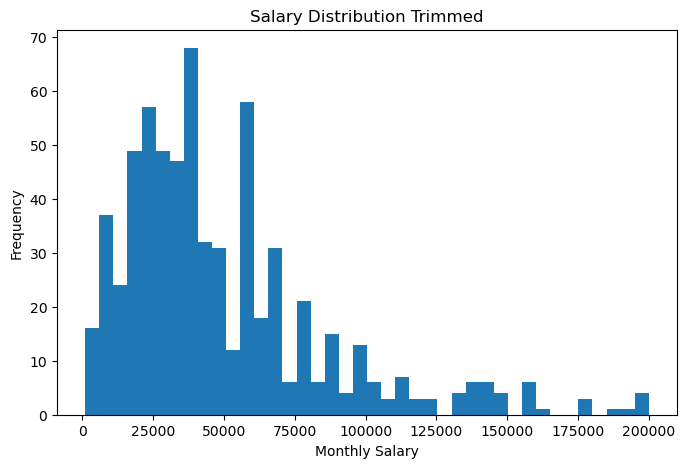

In [5]:
plt.figure(figsize=(8,5))
plt.hist(df_trimmed["salary_minimum"], bins=40)
plt.xlabel("Monthly Salary")
plt.ylabel("Frequency")
plt.title("Salary Distribution Trimmed")
plt.show()

In [6]:
df_trimmed[["salary_minimum","salary_maximum","salary_range"]].describe()

,salary_minimum,salary_maximum,salary_range
count,652.000000,652.000000,652.000000
mean,49911.788727,79067.045757,29155.257030
std,36716.042052,66114.317594,52130.730876
min,1000.000000,1000.000000,0.000000
25%,25000.000000,30000.000000,0.000000
50%,40000.000000,56050.000000,0.000000
75%,64820.000000,120000.000000,33333.333333
max,200000.000000,500000.000000,415000.000000


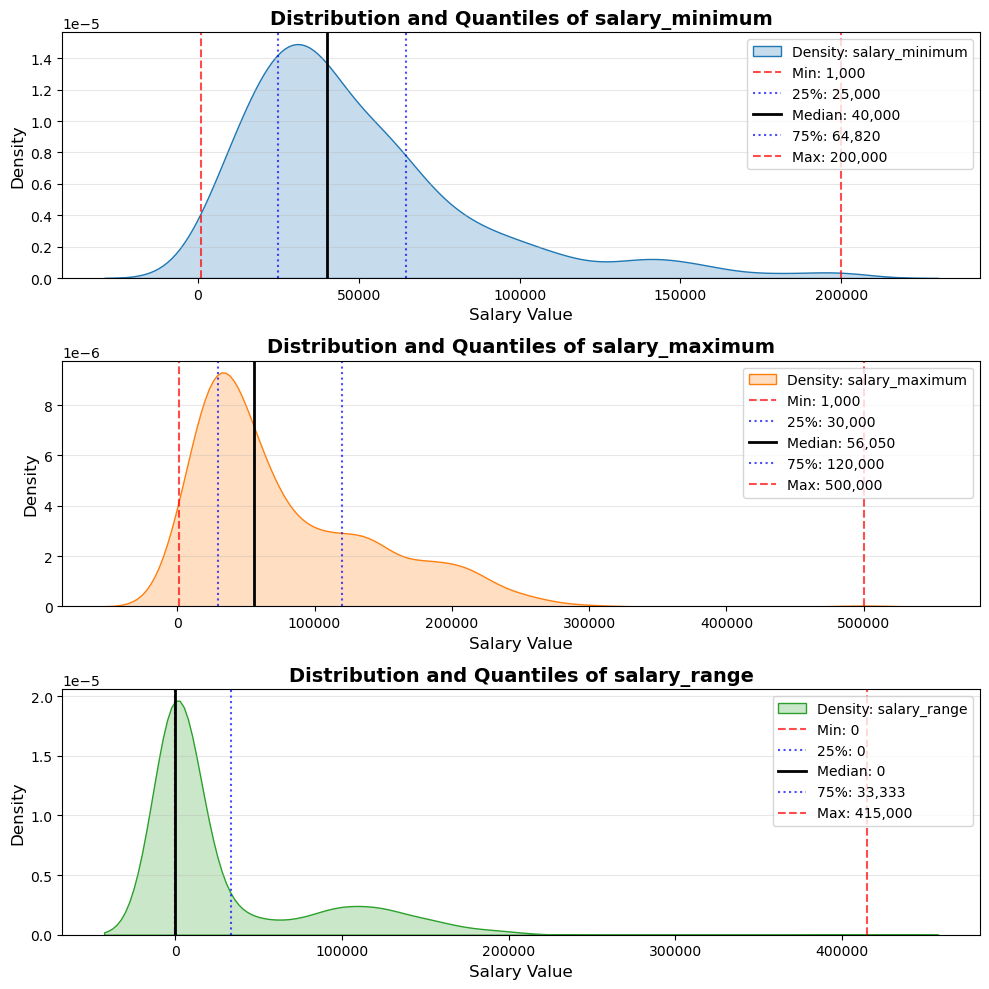

In [7]:
# 2. Define the columns we want to visualize
cols = ['salary_minimum', 'salary_maximum', 'salary_range']

# Plotting of the data
fig, axes = plt.subplots(3, 1, figsize=(10, 10))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green

for i, col in enumerate(cols):
    sns.kdeplot(df_trimmed[col], ax=axes[i], fill=True, color=colors[i], label=f'Density: {col}')
    
    Min = df_trimmed[col].min()
    q1 = df_trimmed[col].quantile(0.25)
    q2 = df_trimmed[col].quantile(0.5)
    q3 = df_trimmed[col].quantile(0.75)
    Max = df_trimmed[col].max()
    metrics = {"Min":Min,"25%":q1,"50%":q2,"75%":q3,"Max":Max}

    axes[i].axvline(metrics['Min'], color='red', linestyle='--', alpha=0.7, label=f"Min: {metrics['Min']:,.0f}")
    axes[i].axvline(metrics['25%'], color='blue', linestyle=':', alpha=0.7, label=f"25%: {metrics['25%']:,.0f}")
    axes[i].axvline(metrics['50%'], color='black', linestyle='-', linewidth=2, label=f"Median: {metrics['50%']:,.0f}")
    axes[i].axvline(metrics['75%'], color='blue', linestyle=':', alpha=0.7, label=f"75%: {metrics['75%']:,.0f}")
    axes[i].axvline(metrics['Max'], color='red', linestyle='--', alpha=0.7, label=f"Max: {metrics['Max']:,.0f}")
    
    axes[i].set_title(f'Distribution and Quantiles of {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Salary Value', fontsize=12)
    axes[i].set_ylabel('Density', fontsize=12)
    axes[i].legend(loc='upper right', fontsize=10)
    axes[i].grid(axis='y', alpha=0.3)

# Adjust layout to prevent overlapping labels
plt.tight_layout()
plt.show()

## 📌 Insights — Salary Distribution
---
- **Right-skewed distribution**: The majority of government jobs cluster in the ₹25,000–₹65,000 minimum salary range, but a long right tail extends up to ₹2,00,000 — indicating a small number of very high-paying elite roles.
- **Median vs Mean gap**: Median minimum salary (₹40,000) is significantly lower than the mean (₹49,912), confirming skew caused by high-salary outliers.
- **Salary range anomaly**: 399 out of 652 jobs (61%) have a `salary_range` of **₹0** — meaning minimum and maximum pay are identical. These are fixed-pay postings with no negotiation band.
- **Maximum salary spread**: The 75th percentile of maximum salary (₹1,20,000) is double the median (₹56,050), showing that the upper tier of government jobs can be significantly more lucrative.
- **Extreme outliers**: A handful of roles offer up to ₹5,00,000 maximum — likely senior PSU or specialist positions.

## 2️⃣ Categorical Distribution Analysis

In [8]:
df_trimmed["qualification_level"].value_counts()

qualification_level
undergraduate    402
postgraduate     134
other             55
diploma           29
school_level      20
doctorate         12
Name: count, dtype: int64

> 📝 **Note:** Government hiring is overwhelmingly targeted at **undergraduate-level** candidates (62%), reflecting broad administrative and officer-grade recruitment drives. Doctoral roles are rare (only 12 postings), indicating that highly specialized academic positions are a niche in public-sector hiring.

In [9]:
# Doctorate and postgraduate roles are concentrated in Education sector.
df_trimmed["sector"].value_counts()

sector
Government General    249
Education             176
Government Admin       54
Banking                50
PSU                    42
Judiciary              27
Energy                 20
Technical/Research     20
Healthcare             14
Name: count, dtype: int64

In [10]:
df_trimmed["role_category"].value_counts()

role_category
Other          206
Managerial      94
Officer         72
Engineer        67
Research        54
Entry Level     54
Assistant       52
Associate       30
Academic        20
Medical          3
Name: count, dtype: int64

In [11]:
df_trimmed["salary_band"].value_counts()

salary_band
Medium       309
Low          204
High         119
Very High     20
Name: count, dtype: int64

### 📊 Visual Representation of Categorical Data

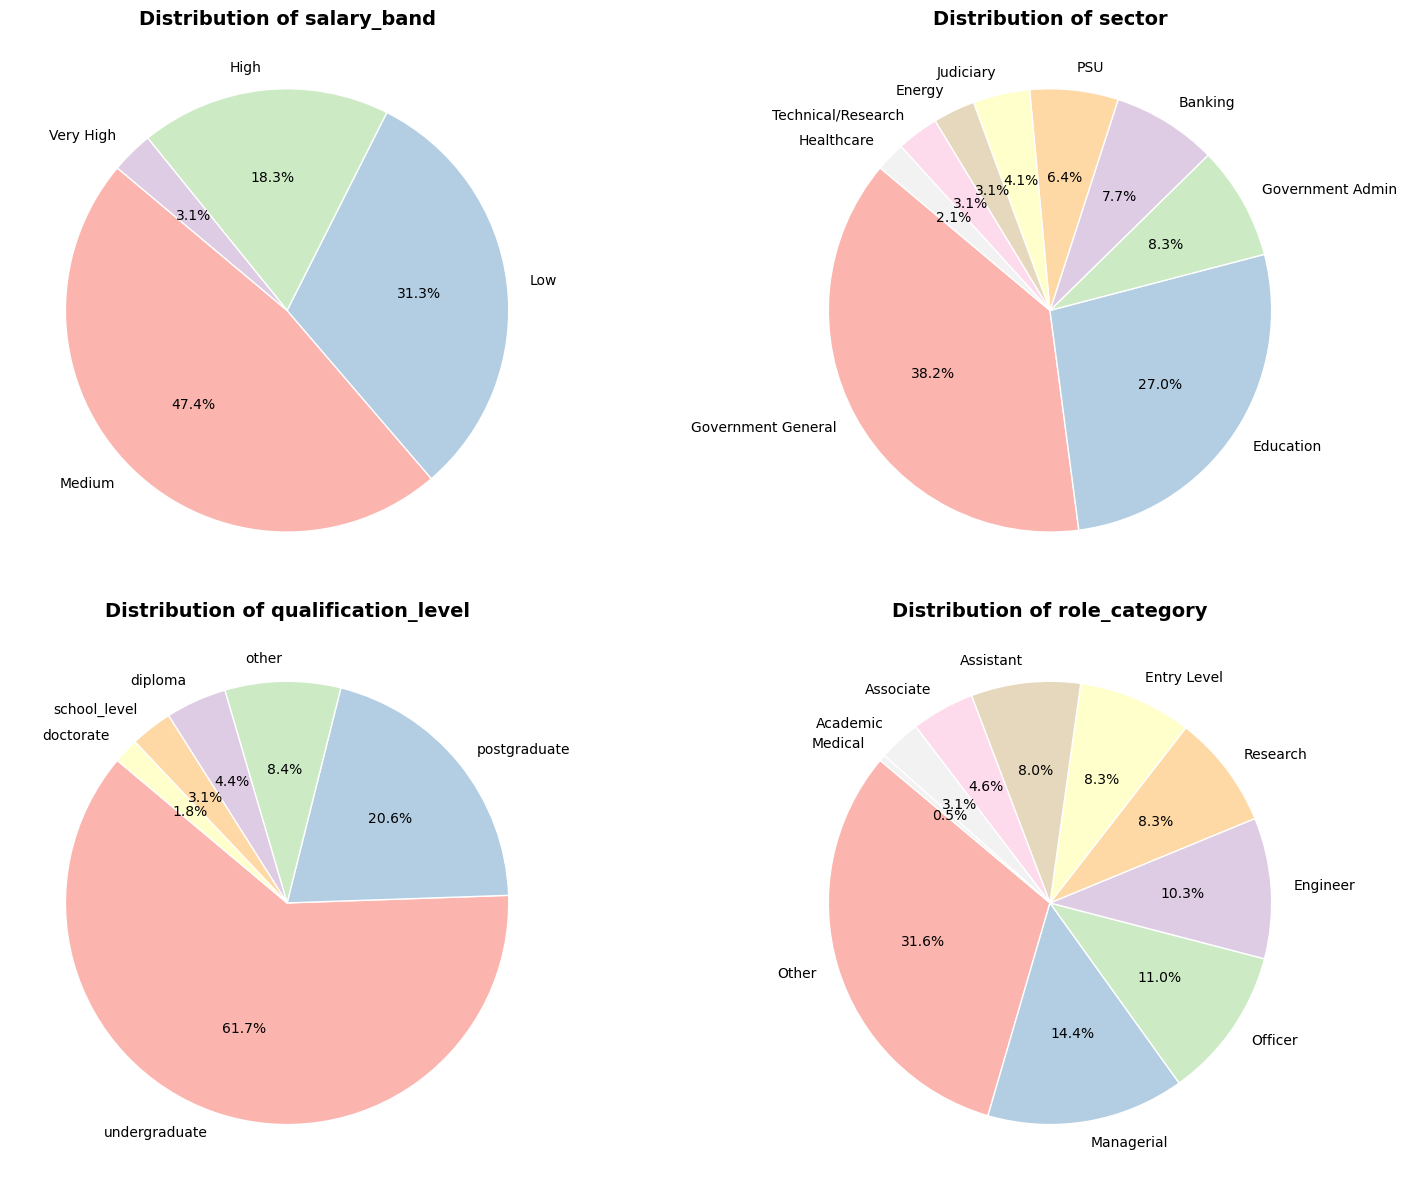

In [5]:
cat_cols = ['salary_band','qualification_level','sector','role_category']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
in_1 = [0,1,0,1]
in_2 = [0,0,1,1]

for i, col in enumerate(cat_cols):
    counts = df_trimmed[col].value_counts()
    # Gpt Code
    axes[in_1[i],in_2[i]].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, 
                colors=plt.cm.Pastel1(range(len(counts))),wedgeprops={'edgecolor': 'white'})
    
    axes[in_1[i],in_2[i]].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("cat.jpg")
plt.show()

### 📌 Insights — Categorical Distributions
---
- **Qualification**: Undergraduate roles dominate (61.7%), followed by postgraduate (20.6%). Doctorate (1.8%) and diploma (4.5%) roles are a small minority — government hiring is a graduate-first ecosystem.
- **Sector**: Government General is the largest employer (38.2%), followed by Education (27%). Together they account for nearly two-thirds of all postings.
- **Role Category**: 'Other' is the largest group (31.6%) — a catch-all category suggesting many government roles are unique in nature. Managerial (14.4%) and Officer (11%) are the next most common.
- **Salary Band**: Most jobs fall in the Medium band (47.4%), with only 3% in the Very High band — reinforcing that high-compensation roles are exceptions, not the norm.

## 3️⃣ Bivariate Analysis

#### 1. Numerical vs Numerical

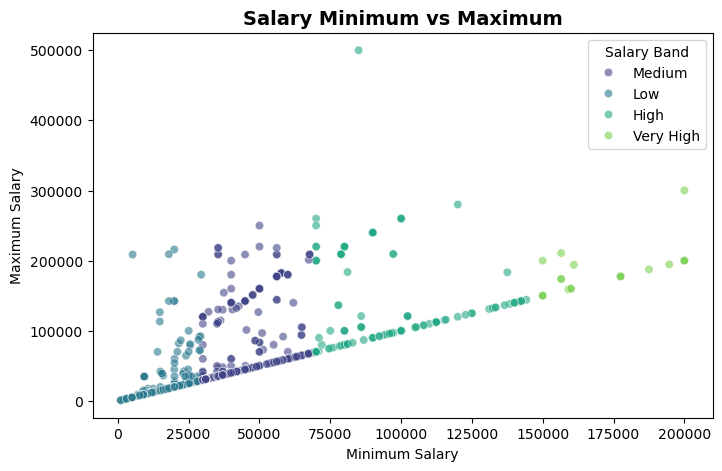

In [13]:
#   1. Numerical to Numerical 
#   Salary_minimum and salary_maximum 
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_trimmed, x='salary_minimum', y='salary_maximum',hue='salary_band' ,alpha=0.6, palette='viridis')
plt.title('Salary Minimum vs Maximum', fontsize=14, fontweight='bold')
plt.xlabel('Minimum Salary')
plt.ylabel('Maximum Salary')
plt.legend(title='Salary Band')
plt.show()

##### 📌 Insight — Min vs Max Salary Correlation
- There is a **strong positive correlation** between minimum and maximum salary — roles with higher floors also have higher ceilings.
- **Low band** jobs are tightly clustered near the origin (₹0–₹30K range), while **Very High band** roles show a wide spread, suggesting significant variability in compensation structure for senior roles.
- The diagonal cluster of points (where min ≈ max) represents the **fixed-pay** postings identified earlier.

#### 2. Numerical to Categorical Columns

##### Analysis Median Minimum and Maximum Salary based on Each category.
`Data is more skewed so we are using median as mesure.`

##### 1️⃣ Median salary by qualification

In [14]:
df_trimmed.groupby("qualification_level")[["salary_minimum", "salary_maximum"]].median().sort_values(by="salary_maximum", ascending=False)

,salary_minimum,salary_maximum
qualification_level,,
doctorate,59500.000000,136950.0
postgraduate,40000.000000,62500.0
other,44900.000000,56900.0
undergraduate,40000.000000,55615.0
school_level,23916.666667,41000.0
diploma,22750.000000,22750.0


##### 2️⃣ Median salary by role_category

In [15]:
df_trimmed.groupby("role_category")[["salary_minimum", "salary_maximum"]].median().sort_values(by="salary_maximum", ascending=False)

,salary_minimum,salary_maximum
role_category,,
Managerial,57216.666667,120940.0
Academic,36400.000000,102350.0
Officer,58050.000000,96765.0
Medical,60000.000000,95000.0
Engineer,45000.000000,56100.0
Other,40000.000000,54650.0
Assistant,35200.000000,48800.0
Associate,30500.000000,37000.0
Research,35400.000000,37000.0


##### 3️⃣ Median salary by sector

In [16]:
df_trimmed.groupby("sector")[["salary_minimum", "salary_maximum"]].agg("median").sort_values(by="salary_maximum", ascending=False)

,salary_minimum,salary_maximum
sector,,
Energy,52500.0,105000.0
Healthcare,56100.0,105000.0
Judiciary,44900.0,80000.0
Government Admin,45415.0,76450.0
PSU,47050.0,70150.0
Government General,40000.0,65000.0
Banking,46740.0,64740.0
Education,35000.0,37000.0
Technical/Research,36000.0,37000.0


C:\Users\midhu\AppData\Local\Temp\ipykernel_6248\3928309593.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_trimmed, x='qualification_level', y='salary_maximum', order=order, palette='Set2')


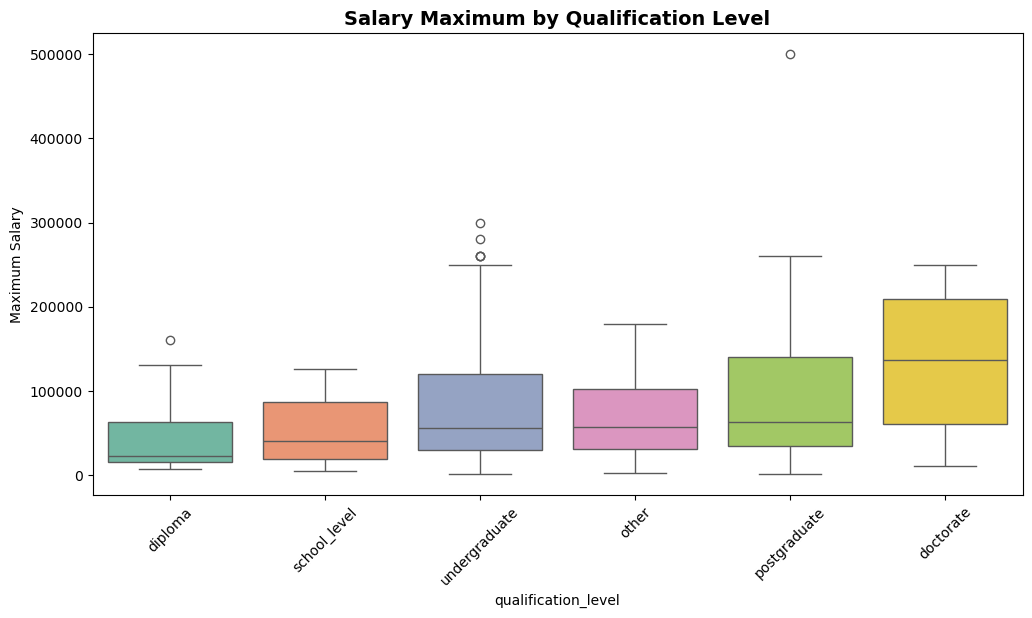

In [18]:
#  Salary_maximum and Qualification level
plt.figure(figsize=(12, 6))
order = df_trimmed.groupby('qualification_level')['salary_maximum'].median().sort_values().index
sns.boxplot(data=df_trimmed, x='qualification_level', y='salary_maximum', order=order, palette='Set2')
plt.title('Salary Maximum by Qualification Level', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Maximum Salary')
plt.show()

C:\Users\midhu\AppData\Local\Temp\ipykernel_6248\3729617186.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_trimmed, x='qualification_level', y='salary_minimum', order=order, palette='Set2')


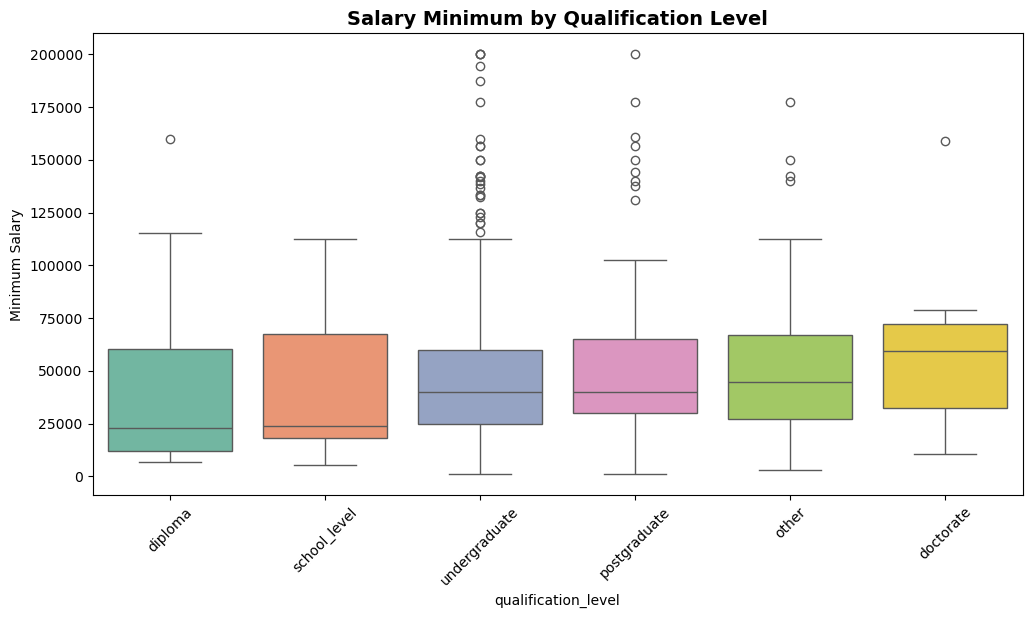

In [19]:
plt.figure(figsize=(12, 6))
order = df_trimmed.groupby('qualification_level')['salary_minimum'].median().sort_values().index
sns.boxplot(data=df_trimmed, x='qualification_level', y='salary_minimum', order=order, palette='Set2')
plt.title('Salary Minimum by Qualification Level', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Minimum Salary')
plt.show()

In [20]:
# Categorical columns to compare
cats = ['role_category', 'qualification_level', 'sector']

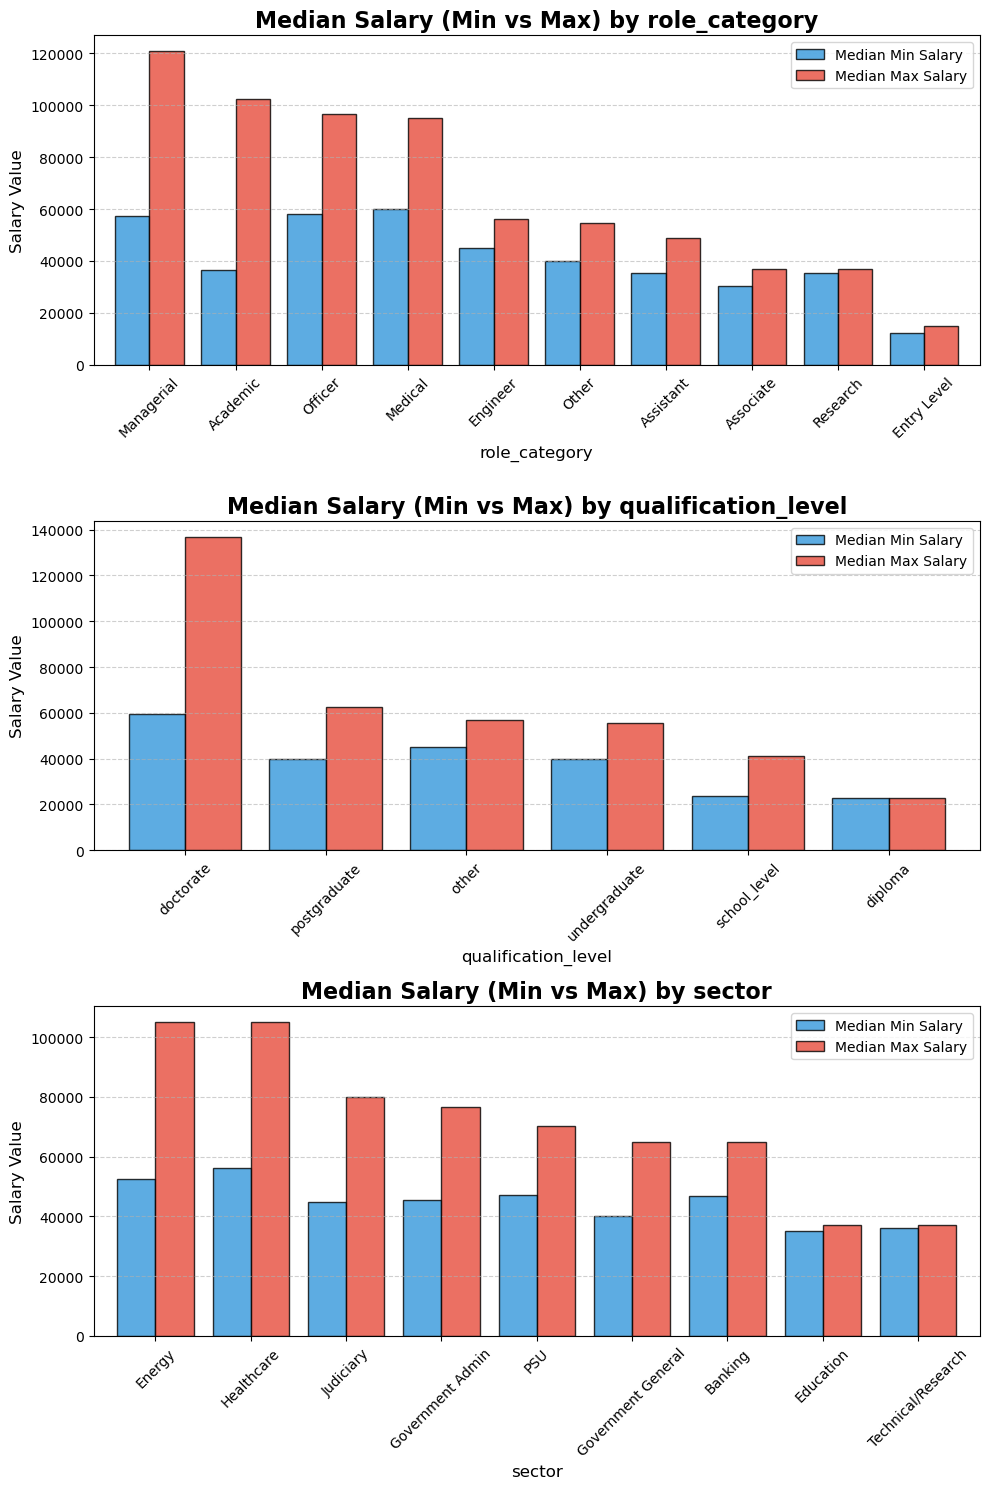

In [21]:
# Define a 3-row layout for comparison
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

for i, cat in enumerate(cats):
    grouped_df = df_trimmed.groupby(cat)[['salary_minimum', 'salary_maximum']].median().sort_values(by='salary_maximum', ascending=False)
    grouped_df.plot(kind='bar', ax=axes[i], color=['#3498db', '#e74c3c'], width=0.8, edgecolor='black', alpha=0.8)
    
    axes[i].set_title(f'Median Salary (Min vs Max) by {cat}', fontsize=16, fontweight='bold')
    axes[i].set_ylabel('Salary Value', fontsize=12)
    axes[i].set_xlabel(cat, fontsize=12)
    axes[i].legend(["Median Min Salary", "Median Max Salary"], loc='upper right', frameon=True)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# Final formatting
plt.tight_layout()
plt.show()

### 📌 Insights — Salary by Qualification, Role & Sector
---
**By Qualification Level:**
- **Doctorate** holders command the highest median maximum salary at ₹1,36,950 — nearly **2.5× that of undergraduates** (₹55,615).
- However, doctorate roles are scarce (only 12 postings), so this premium reflects exclusivity, not broad opportunity.
- Postgraduate salaries (₹62,500 median max) are only marginally higher than undergraduate (₹55,615) — a surprisingly small premium for an additional degree in the government sector.
- Diploma holders earn the least (₹22,750 median max), even below school-level, possibly due to technical apprenticeship roles.

**By Role Category:**
- **Managerial** roles top the charts (₹1,20,940 median max), but **Academic** roles are a surprising second (₹1,02,350), likely driven by senior professor/dean positions in public universities.
- **Entry Level** roles have the lowest median maximum salary at ₹15,000 — a 8× gap compared to Managerial roles.
- Officer roles (₹96,765) rank third, driven by Banking and Government Admin officers.

**By Sector:**
- **Energy** and **Healthcare** sectors tie at the top with a median maximum of ₹1,05,000 — likely due to specialized/technical nature of roles.
- **Education** and **Technical/Research** sectors have the lowest median maximum (₹37,000), which is counterintuitive given their academic prestige — suggesting most postings are for non-senior positions.
- Government General, despite being the largest employer, offers only a mid-range median max of ₹65,000.

### Categorical vs Categorical

#### 1. No of jobs between Role_category and Sector 

In [36]:
pd.crosstab(df_trimmed["role_category"], df_trimmed["sector"])

sector,Banking,Education,Energy,Government Admin,Government General,Healthcare,Judiciary,PSU,Technical/Research
role_category,,,,,,,,,
Academic,0,9,0,8,3,0,0,0,0
Assistant,4,16,1,7,14,0,7,2,1
Associate,1,20,0,1,7,0,0,0,1
Engineer,0,13,3,6,30,0,0,12,3
Entry Level,7,3,4,1,33,0,0,4,2
Managerial,12,7,7,2,55,1,0,10,0
Medical,0,0,0,0,3,0,0,0,0
Officer,12,15,2,11,23,3,1,4,1
Other,14,53,2,17,74,10,16,10,10


In [37]:
cat_ct = pd.crosstab(df_trimmed['sector'], df_trimmed['role_category'])

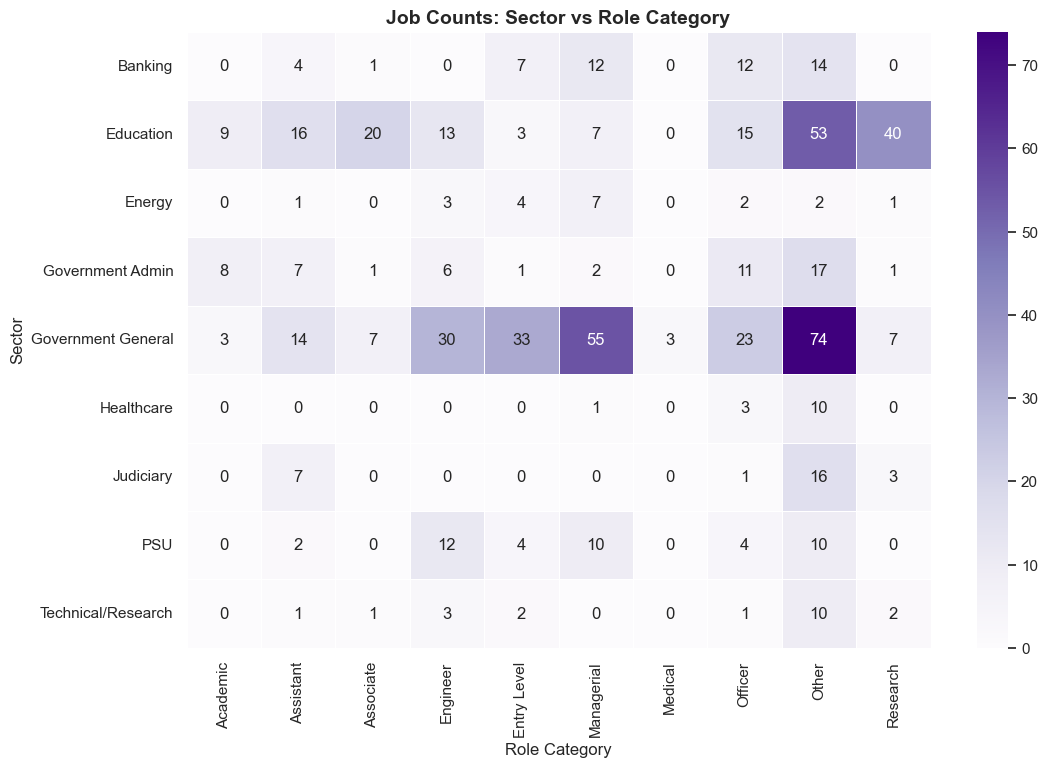

In [38]:
# --- Visualization A: Heatmap (Raw Counts) ---
plt.figure(figsize=(12, 8))
sns.heatmap(cat_ct, annot=True, fmt='d', cmap='Purples', linewidths=.5)
plt.title('Job Counts: Sector vs Role Category', fontsize=14, fontweight='bold')
plt.xlabel('Role Category', fontsize=12)
plt.ylabel('Sector', fontsize=12)
plt.show()

#### 2. No of jobs between Qualification and Sector 

In [22]:
pd.crosstab(df_trimmed["qualification_level"], df_trimmed["sector"])

sector,Banking,Education,Energy,Government Admin,Government General,Healthcare,Judiciary,PSU,Technical/Research
qualification_level,,,,,,,,,
diploma,0,2,2,5,11,2,1,6,0
doctorate,0,8,0,1,3,0,0,0,0
other,4,16,0,3,18,4,5,3,2
postgraduate,9,53,2,9,49,3,3,2,4
school_level,1,6,1,3,6,0,1,2,0
undergraduate,36,91,15,33,162,5,17,29,14


In [23]:
cat_ct = pd.crosstab(df_trimmed['sector'], df_trimmed['qualification_level'])

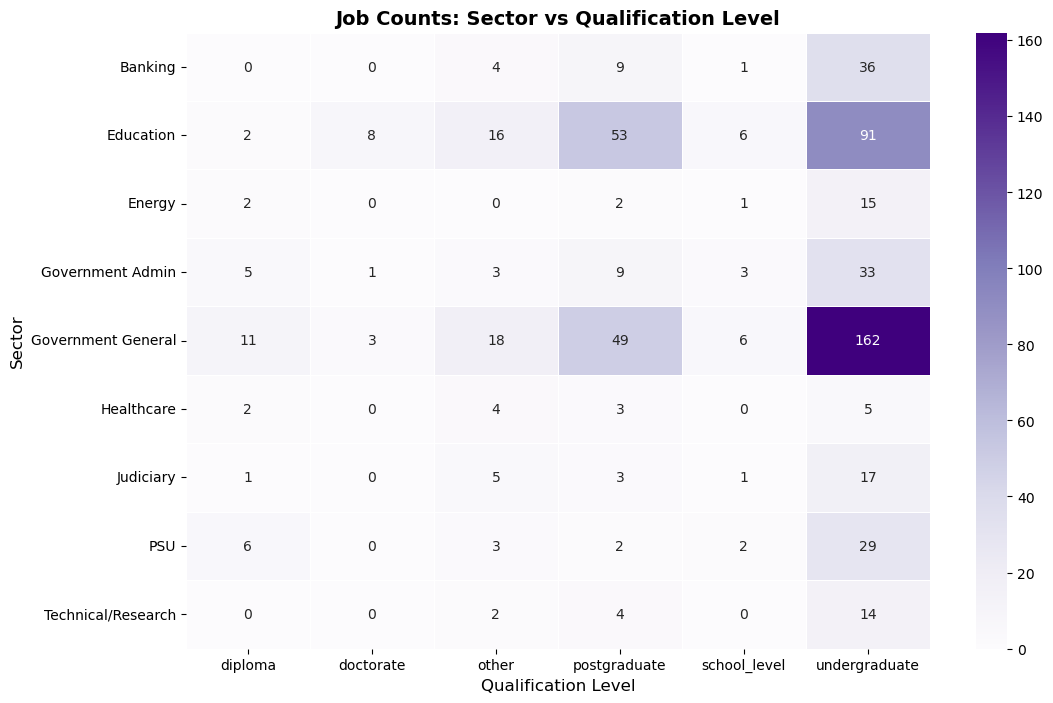

In [24]:
# --- Visualization A: Heatmap (Raw Counts) ---
plt.figure(figsize=(12, 8))
sns.heatmap(cat_ct, annot=True, fmt='d', cmap='Purples', linewidths=.5)
plt.title('Job Counts: Sector vs Qualification Level', fontsize=14, fontweight='bold')
plt.xlabel('Qualification Level', fontsize=12)
plt.ylabel('Sector', fontsize=12)
plt.show()

### 📊 Stacked Bar Chart — Qualification Proportion by Sector

In [25]:
# Normalize the table to 100% so we can compare proportions across sectors
cat_ct_pct = pd.crosstab(df_trimmed['sector'], df_trimmed['qualification_level'], normalize='index') * 100

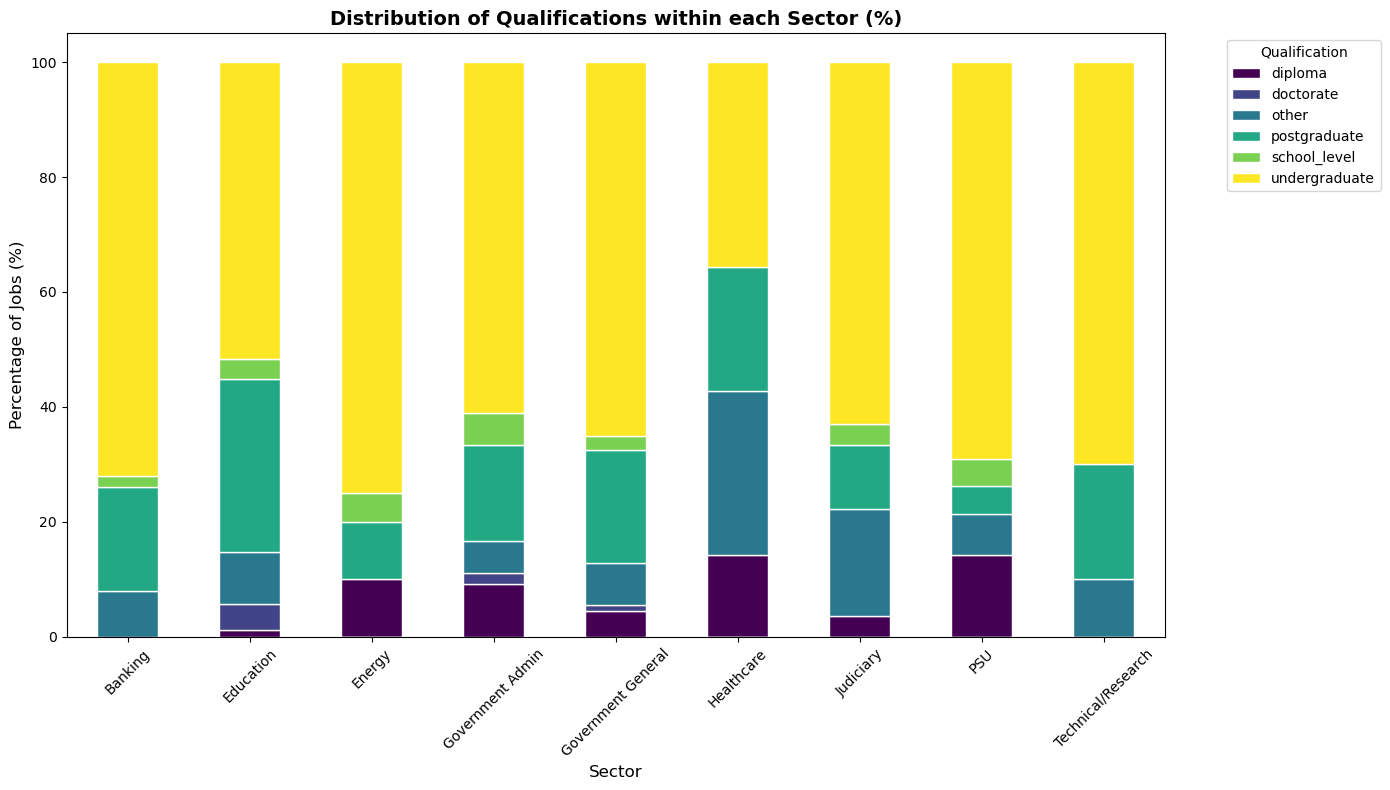

In [29]:
# Plotting
ax = cat_ct_pct.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='viridis', edgecolor='white')
# Formatting
plt.title('Distribution of Qualifications within each Sector (%)', fontsize=14, fontweight='bold')
plt.ylabel('Percentage of Jobs (%)', fontsize=12)
plt.xlabel('Sector', fontsize=12)
plt.legend(title='Qualification', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 📌 Insight — Sector vs Qualification Heatmap
- **Education** sector is the primary consumer of postgraduate talent (53 postings) and doctorates (8), which aligns with its academic nature.
- **Government General** is the single largest hirer of undergraduates (162 postings) — nearly 40% of all undergraduate roles.
- **Banking** exclusively hires undergraduates and postgraduates — zero diploma or doctorate roles.
- **PSU** shows diverse qualification hiring but leans heavily undergraduate (29 of 42 roles).
- The stacked bar chart confirms that **undergraduate qualification is the norm across every sector** without exception.

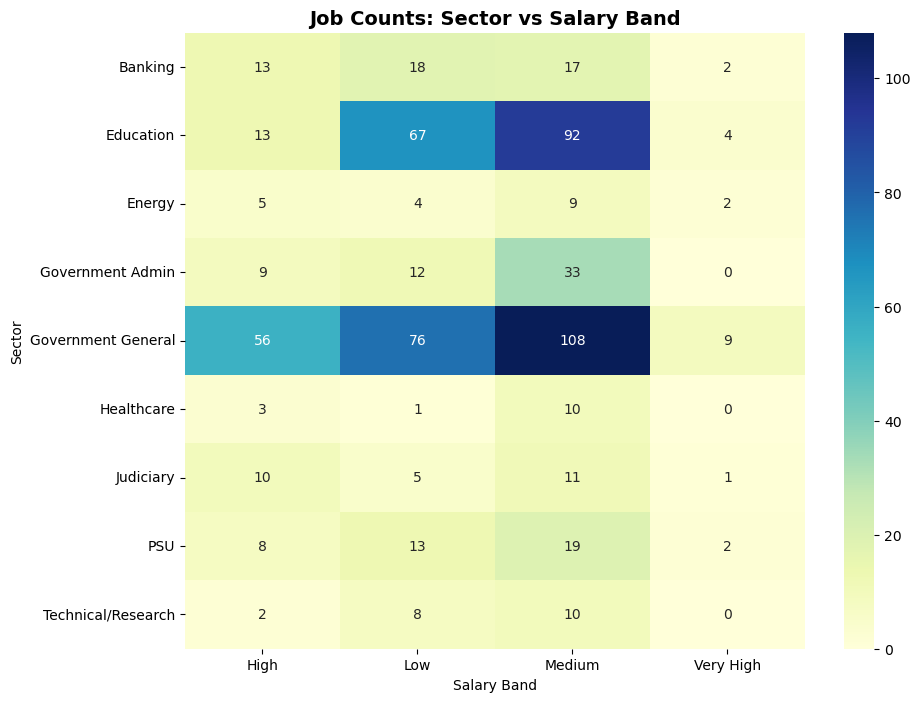

In [28]:
# --- 3. Categorical to Categorical (Heatmap) ---
# Create a cross-tabulation of two categorical variables
ct = pd.crosstab(df_trimmed['sector'], df_trimmed['salary_band'])
plt.figure(figsize=(10, 8))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Job Counts: Sector vs Salary Band', fontsize=14, fontweight='bold')
plt.xlabel('Salary Band')
plt.ylabel('Sector')
plt.show()

##### 📌 Insight — Sector vs Salary Band
- **Governament General** has the highest concentration of High and Very High salary band postings relative to its size, confirming its reputation as a well-paying segment of government employment.
- **Education** and **Technical/Research** sectors are dominated by Low and Medium salary bands, consistent with their low median salary figures.
- **Judiciary** shows a notable proportion of Medium-to-High bands despite limited postings — suggesting that judicial roles are consistently well-compensated.

## 4️⃣ Multivariate Analysis

#### 1. Min vs Max Salary by Role Category (Scatter Plot)
---

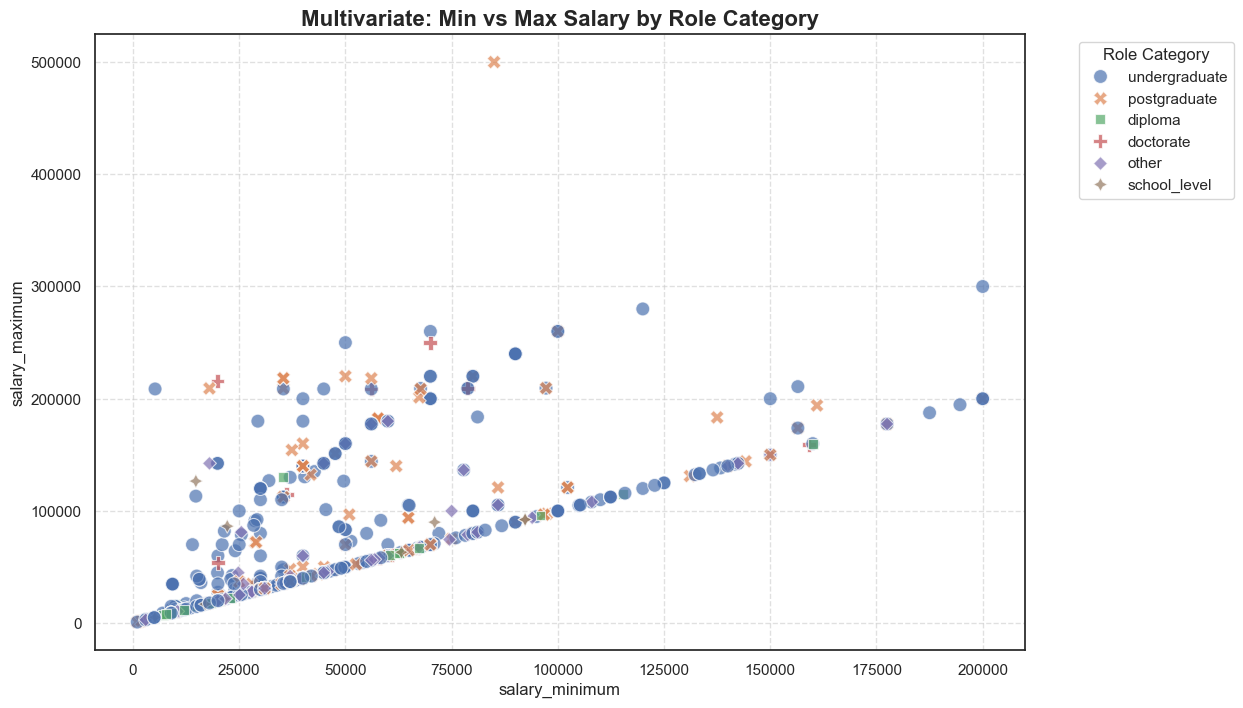

In [32]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_trimmed, x='salary_minimum', y='salary_maximum', 
                hue='qualification_level', style='qualification_level', s=100, alpha=0.7)
plt.title('Multivariate: Min vs Max Salary by Role Category', fontsize=16, fontweight='bold')
plt.legend(title='Role Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

##### 📌 Insight — Multivariate Salary Scatter
- **Doctorate** holders are spread across the entire salary spectrum but occupy more of the upper-right quadrant (high min, high max), confirming their salary premium.
- **Undergraduate** points are densely packed in the low-to-medium zone, but some outliers reach very high salary bands — these are likely senior officer or managerial undergraduate roles.
- **School-level** qualifications are tightly clustered near low values with minimal spread — very little salary upside in this tier.

#### 2. Average Salary Heatmap (Sector vs Qualification) 
---

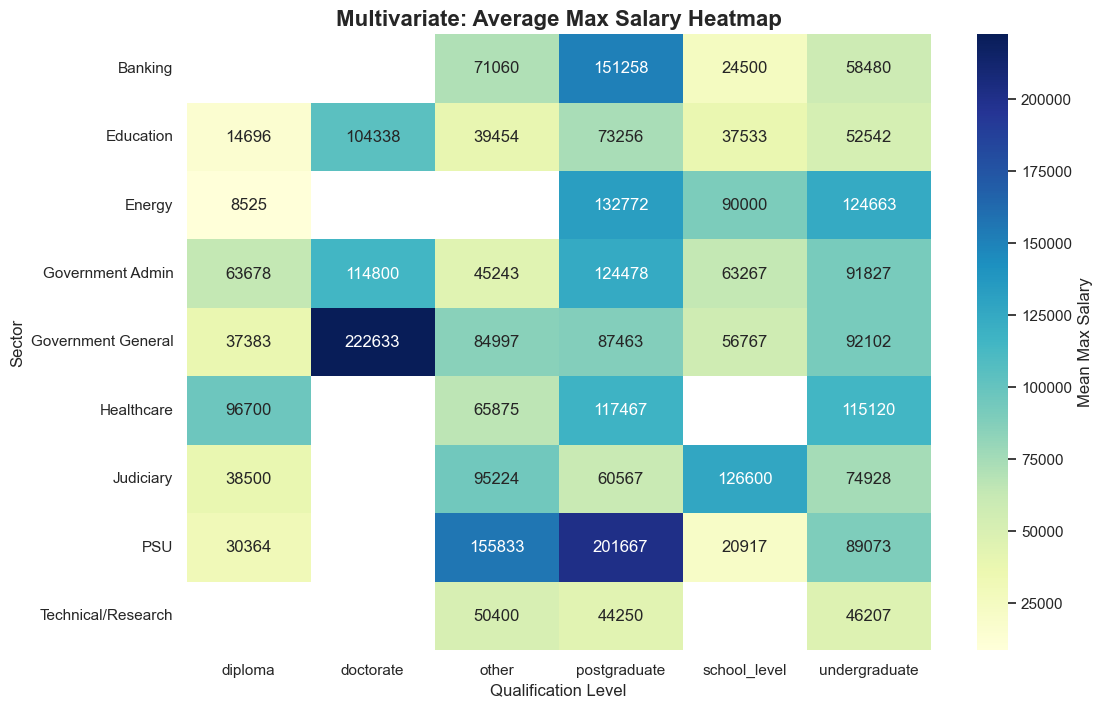

In [33]:
# We use a pivot table to get the mean salary for each combination
pivot_table = df_trimmed.pivot_table(values='salary_maximum', index='sector', columns='qualification_level', aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap='YlGnBu', cbar_kws={'label': 'Mean Max Salary'})
plt.title('Multivariate: Average Max Salary Heatmap', fontsize=16, fontweight='bold')
plt.xlabel('Qualification Level')
plt.ylabel('Sector')
plt.show()

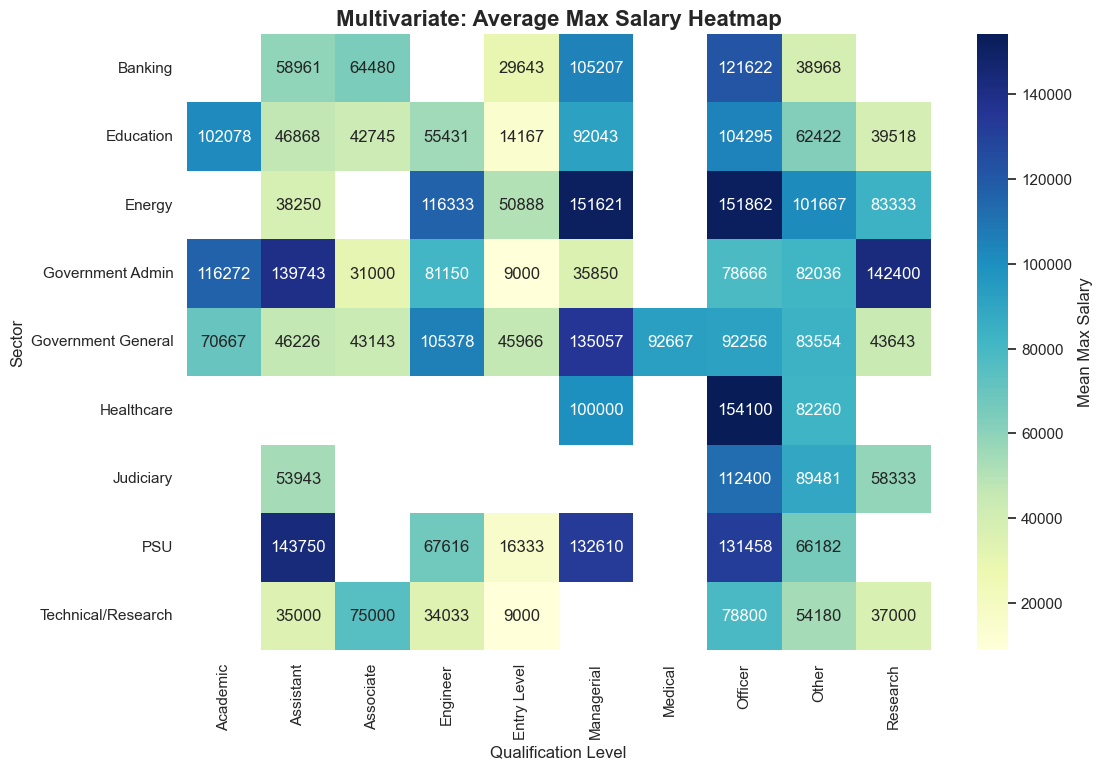

In [34]:
# We use a pivot table to get the mean salary for each combination
pivot_table = df_trimmed.pivot_table(values='salary_maximum', index='sector', columns='role_category', aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap='YlGnBu', cbar_kws={'label': 'Mean Max Salary'})
plt.title('Multivariate: Average Max Salary Heatmap', fontsize=16, fontweight='bold')
plt.xlabel('Qualification Level')
plt.ylabel('Sector')
plt.show()

##### 📌 Insight — Average Max Salary Heatmap (Sector × Qualification & Role)
- **PSU + Undergraduate Managerial** and **Banking + Postgraduate Managerial** combinations yield the highest average maximum salaries.
- **Education + Doctorate** roles show high average salaries (as expected), but the combination is rare.
- Many cells in the heatmaps are NaN (blank) — indicating that not all sector-qualification-role combinations exist in the dataset. Government hiring follows structured, non-arbitrary patterns.
- The **Government General × Undergraduate** cell has the largest sample size, making it the most reliable data point — and it shows a moderate average max salary of ~₹65,000.

### 3. Compare Core vs Elite

In [ ]:
# Define salary ceiling using IQR method
Q3 = df_trimmed['salary_minimum'].quantile(0.75)
Q1 = df_trimmed['salary_minimum'].quantile(0.25)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR  # ₹1,24,550

df_elite = df_trimmed[df_trimmed['salary_minimum'] > upper_limit]
print(f'Elite postings (salary_minimum > ₹{upper_limit:,.0f}): {len(df_elite)} roles')

In [ ]:
df_elite[['qualification_level', 'sector', 'role_category']].value_counts().head(15)

###  Data which have most elites.
- Undergraduate → Managerial (PSU)
- Undergraduate → Officer (Banking / Govt General)
- Postgraduate → Managerial (PSU)

## 🔍 Final Insights Summary

## 🏁 Conclusion — The Data Story
---
This analysis of 652 government job postings reveals a clear and consistent pattern:

**1. Qualification has diminishing returns in government hiring.**
The jump from undergraduate (₹55,615 median max) to postgraduate (₹62,500) is modest — just ~12%. Only doctorates see a dramatic premium (₹1,36,950), but those roles are extremely rare (1.8% of all postings). In practice, most government salary is determined more by *role and sector* than by academic level.

**2. Role category is the strongest salary predictor.**
Managerial roles earn 8× more than Entry Level on the median maximum salary metric. Surprisingly, Academic roles rank second — not Engineering or Medical — suggesting senior public university positions are highly compensated.

**3. Sector determines the salary ceiling.**
Energy and Healthcare top the sector ladder (₹1,05,000 median max), while Education — despite being the second-largest employer — sits near the bottom (₹37,000). This suggests that sector prestige and posting volume are inversely related in government.

**4. Elite roles follow a specific profile.**
High-salary outliers (above ₹1,24,550 minimum) are concentrated in:
- Undergraduate → Managerial → Government General / PSU
- Postgraduate → Officer → Banking
This tells us that *seniority and sector matter more than academic credentials* when it comes to reaching the top of the pay scale.

**5. The government salary structure is bimodal.**
The majority of roles (61%) have zero salary range (fixed pay), and most cluster in Medium/Low bands. A small elite tier (3% Very High band) skews the averages significantly — making median a more honest measure than mean throughout this analysis.